In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from collections import Counter

# Acessing the real data 

In [2]:
data = pd.read_csv("netflix_titles.csv")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# checking information about data 

In [3]:
# Check basic info
data.info()
# Check null values
data.isnull()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
print("Missing values:")
print(data.isnull().sum())

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


# clearing data and modifing according to need

In [5]:
data["date_added"] = pd.to_datetime(data["date_added"], errors="coerce")
data["year_added"] = data["date_added"].dt.year
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


# filtering duration in minutes and seasons 

In [6]:
data[["duration_num", "duration_type"]] = data["duration"].str.extract(r"(\d+)\s*(\w+)")
data["duration_num"] = data["duration_num"].astype(float)
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_num,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,90.0,min
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,2.0,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,1.0,Season
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,2.0,Seasons


In [7]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
data = data[data["year_added"] >= 2000]

# Titles added per year 

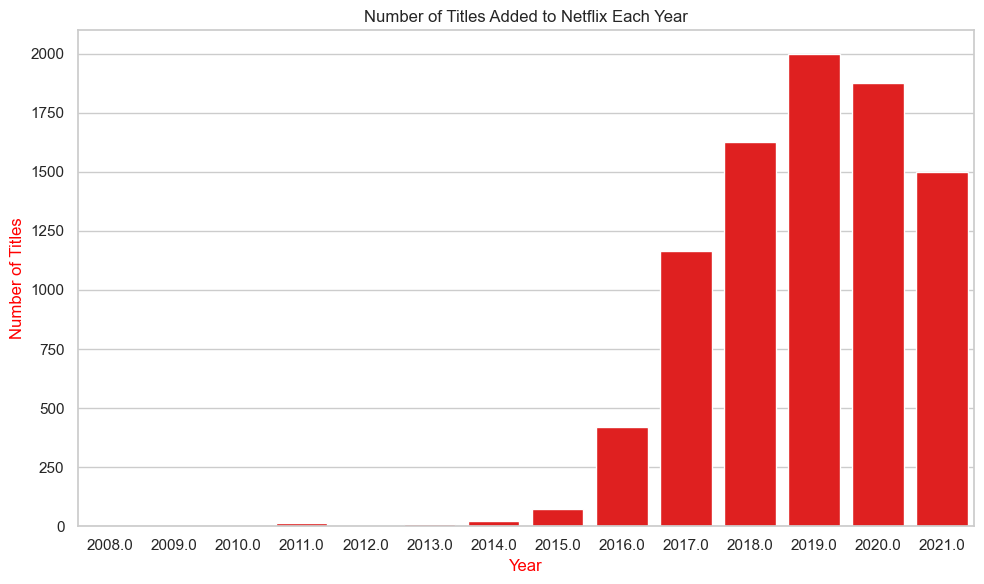

In [8]:
plt.figure(figsize=(10,6))
sns.countplot(data=data, x="year_added",color="red")
plt.title("Number of Titles Added to Netflix Each Year")
plt.xlabel("Year",color="red")
plt.ylabel("Number of Titles",color="red")
plt.tight_layout()
plt.show()

#  TV Shows vs Movies

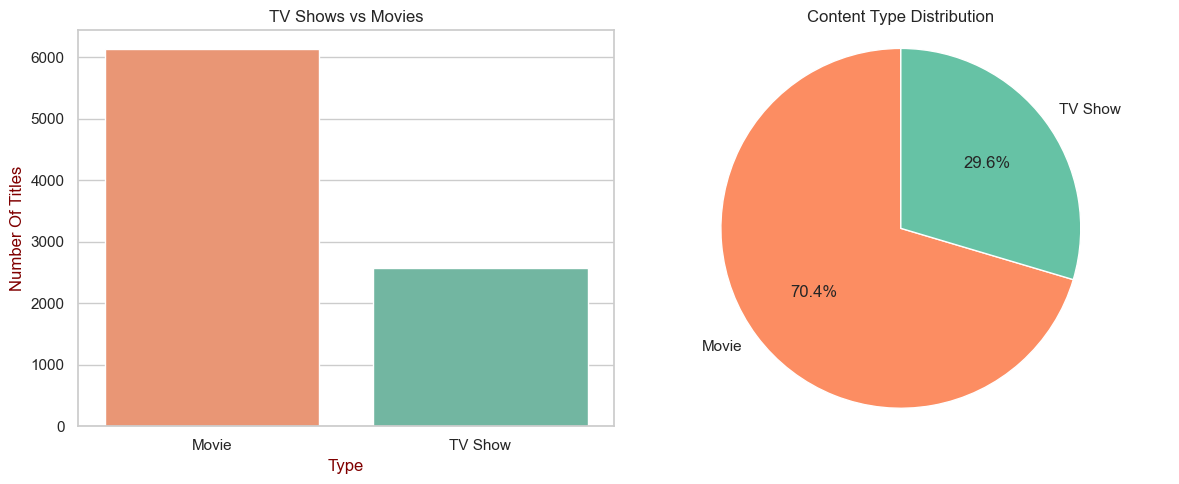

In [9]:
type_counts = data["type"].value_counts()
colors = sns.color_palette("Set2", n_colors=len(type_counts))[::-1]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=data, x="type", hue="type", palette=colors, legend=False, ax=axes[0])
axes[0].set_title("TV Shows vs Movies")
axes[0].set_xlabel("Type",color="maroon")
axes[0].set_ylabel("Number Of Titles",color="maroon")
axes[1].pie(type_counts, labels=type_counts.index, autopct="%1.1f%%", startangle=90, colors=colors)
axes[1].set_title("Content Type Distribution")
axes[1].axis("equal")
plt.tight_layout()
plt.show()

#    Top 10 Genres

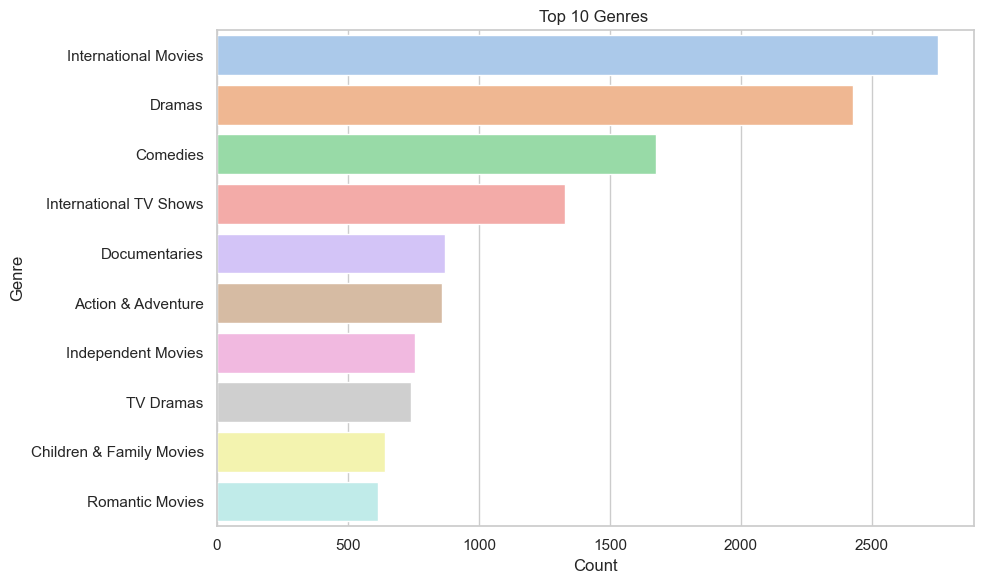

In [10]:
all_genres = ','.join(data['listed_in'].dropna()).split(',')
genre_counts = Counter([genre.strip() for genre in all_genres])
genre_series = pd.Series(genre_counts).sort_values(ascending=False)
top10 = genre_series.head(10).reset_index()
top10.columns = ["Genre", "Count"]
sns.barplot(data=top10, x="Count", y="Genre", hue="Genre", palette="pastel", legend=False)
plt.title("Top 10 Genres ")
plt.tight_layout()
plt.show()


#  TV Shows vs Movies by Rating (Top 10 Ratings)

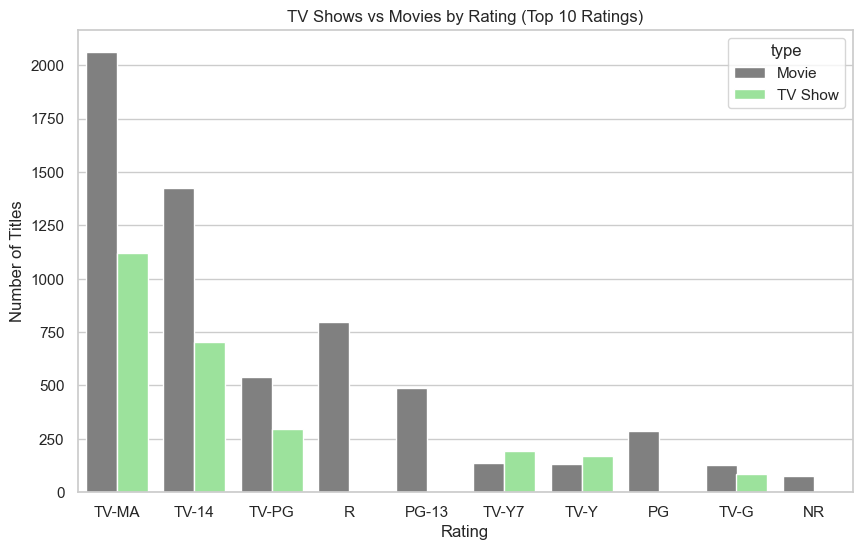

In [11]:
top_ratings = data["rating"].value_counts().nlargest(10).index
filtered = data[data["rating"].isin(top_ratings)]
custom_palette = {"Movie": "gray","TV Show": "lightgreen"}
sns.countplot(data=filtered,x="rating",hue="type",order=top_ratings,palette=custom_palette)
plt.title("TV Shows vs Movies by Rating (Top 10 Ratings)")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.tight_layout
plt.show()

#  Rating distribution According To Content 

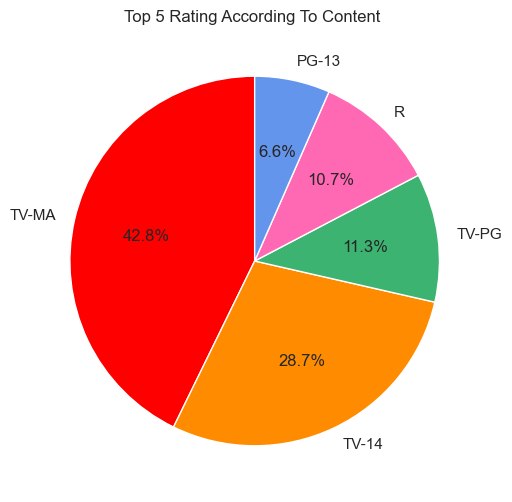

In [12]:
topratings = data["rating"].value_counts().nlargest(5)
color =  ["red", "darkorange", "mediumseagreen","hotpink" ,"cornflowerblue"]
topratings.plot.pie(autopct='%1.1f%%',colors =color , startangle=90)
plt.title("Top 5 Rating According To Content ")
plt.ylabel("")
plt.show()

#  Genre Diversity Over Time

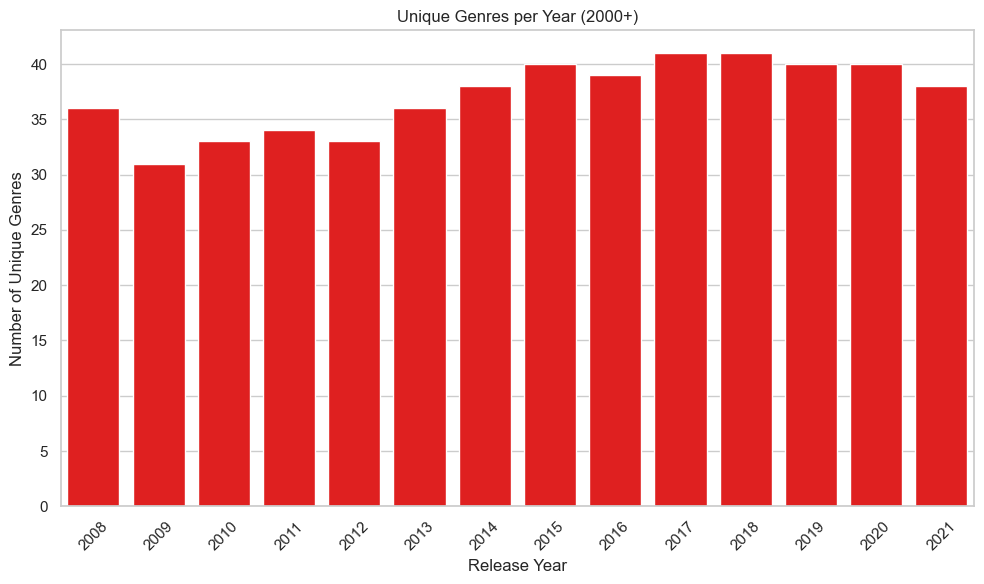

In [13]:
data = data[data["release_year"] >= 2008].copy()
data["genre_list"] = data["listed_in"].fillna('').str.split(",").apply(lambda x: [g.strip() for g in x])
genre_diversity = data.explode("genre_list").groupby("release_year")["genre_list"].nunique().reset_index()
genre_diversity.columns = ["release_year", "unique_genres"]
sns.barplot(data=genre_diversity, x="release_year", y="unique_genres", color="red")
plt.title("Unique Genres per Year (2000+)")
plt.xlabel("Release Year")
plt.ylabel("Number of Unique Genres")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  Distribution of TV-MA (Mature) Content by Year(Creative Freedom)


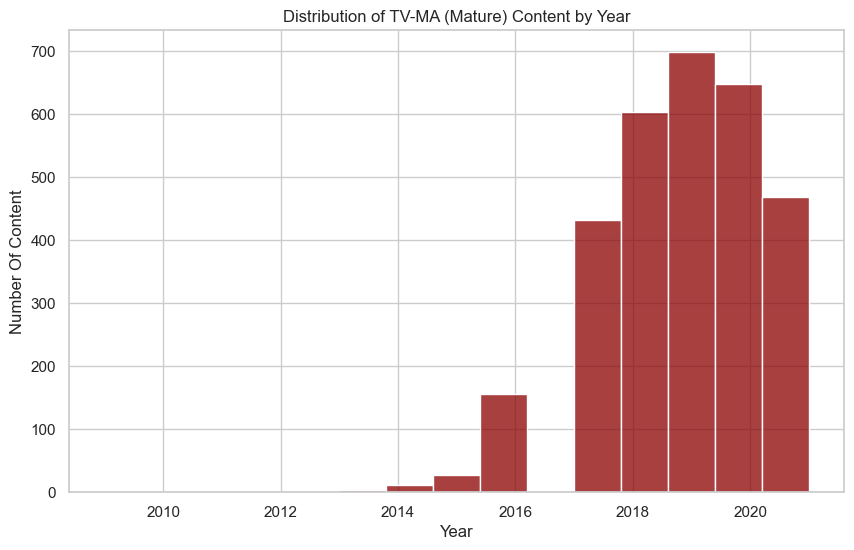

In [14]:
tvma = data[data["rating"] == "TV-MA"]
sns.histplot(tvma["year_added"], bins=15, kde=False, color="darkred")
plt.title("Distribution of TV-MA (Mature) Content by Year")
plt.xlabel("Year")
plt.ylabel("Number Of Content")
plt.show()

# Growth of Bold Content Cultural Shift Toward Boldness

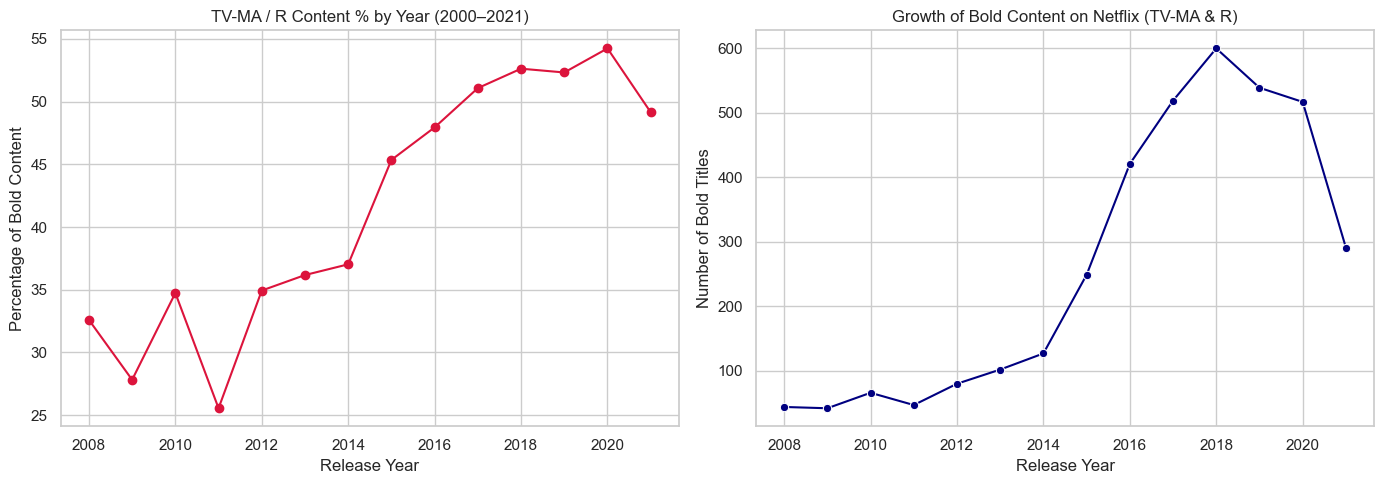

In [15]:
data = data[data["release_year"] >= 2008].copy()
mature = data[data["rating"].isin(["TV-MA", "R"])]
maturebyyear = mature["release_year"].value_counts().sort_index()
totalbyyear = data["release_year"].value_counts().sort_index()
maturepctr = (maturebyyear / totalbyyear) * 100
boldbyear = mature["release_year"].value_counts().sort_index()
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(maturepctr.index, maturepctr.values, marker="o", color="crimson")
plt.title("TV-MA / R Content % by Year (2000–2021)")
plt.xlabel("Release Year")
plt.ylabel("Percentage of Bold Content")
plt.grid(True)
plt.subplot(1, 2, 2)
sns.lineplot(x=boldbyear.index, y=boldbyear.values, marker="o", color="navy")
plt.title("Growth of Bold Content on Netflix (TV-MA & R)")
plt.xlabel("Release Year")
plt.ylabel("Number of Bold Titles")
plt.grid(True)
plt.tight_layout()
plt.tight_layout()
plt.show()

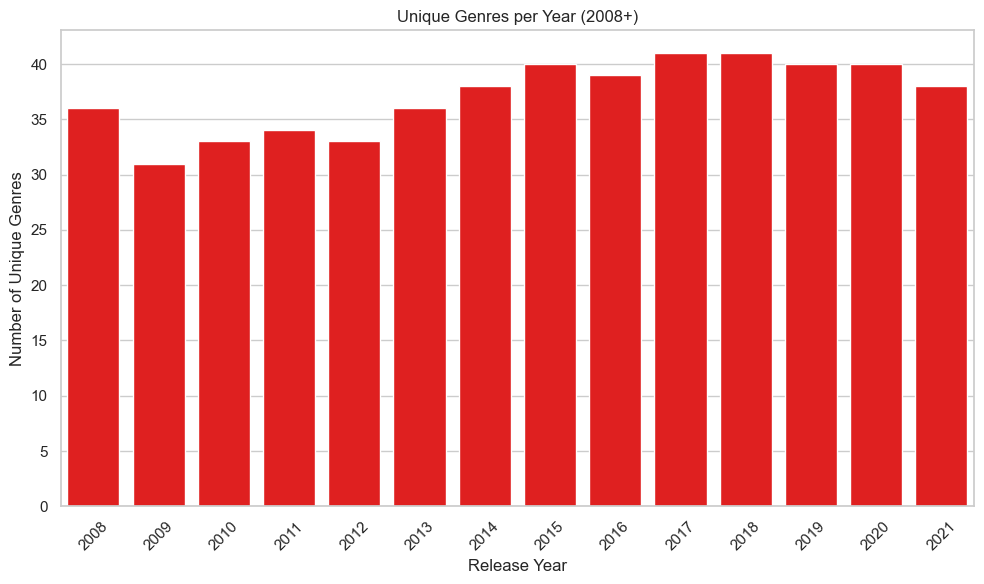

In [17]:
data = data[data["release_year"] >= 2008].copy()
data["genre_list"] = data["listed_in"].fillna('').str.split(",").apply(lambda x: [g.strip() for g in x])
genre_diversity = data.explode("genre_list").groupby("release_year")["genre_list"].nunique().reset_index()
genre_diversity.columns = ["release_year", "unique_genres"]
sns.barplot(data=genre_diversity, x="release_year", y="unique_genres", color="red")
plt.title("Unique Genres per Year (2008+)")
plt.xlabel("Release Year")
plt.ylabel("Number of Unique Genres")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
